# 06 Forecasts

This notebook generates probabilistic VAR forecast trajectories using different innovation models.

Innovation models:

- Gaussian
- Bootstrap
- Student-t
- Diffusion

The goal is to propagate sampled future shocks through the fitted VAR recursion and save forecast paths for later calibration evaluation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.seeds import set_seed
from src.utils.logging_utils import make_run_dir, save_metrics_json, save_table_csv
from src.data.loaders import load_npz, save_npz

from src.forecasting.monte_carlo import simulate_forecast_paths
from src.forecasting.intervals import prediction_interval, median_forecast, average_interval_width
from src.evaluation.metrics import summarize_probabilistic_forecast, make_summary_row

set_seed(123)

In [2]:
dgp_names = [
    "gaussian",
    "student_t",
    "mixture",
    "heteroskedastic",
]

innovation_model_names = [
    "gaussian",
    "bootstrap",
    "student_t",
    "diffusion",
]

lags = 1
n_train = 300
horizon = 40
n_paths = 250

simulated_dir = ROOT / "data" / "simulated"
var_fit_dir = ROOT / "results" / "models" / "02_var_deepar_fit"
classic_innov_dir = ROOT / "results" / "innovations" / "04_innovations"
diffusion_innov_dir = ROOT / "results" / "innovations" / "05_diffusion"

forecast_dir = ROOT / "results" / "forecasts" / "06_forecasts"
table_dir = ROOT / "results" / "tables" / "06_forecasts"

forecast_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

In [3]:
datasets = {}
var_fits = {}

for dgp_name in dgp_names:
    dgp_data = load_npz(
        simulated_dir / f"{dgp_name}_var_dgp.npz"
    )

    y = dgp_data["y"]
    y_train = y[:n_train]
    y_test = y[n_train:n_train + horizon]

    datasets[dgp_name] = {
        "y": y,
        "y_train": y_train,
        "y_test": y_test,
    }

    fit_data = load_npz(
        var_fit_dir / f"{dgp_name}_var_fit.npz"
    )

    var_fits[dgp_name] = {
        "beta": fit_data["beta"],
        "Sigma_hat": fit_data["Sigma_hat"],
    }

    print(
        dgp_name,
        "train:",
        y_train.shape,
        "test:",
        y_test.shape,
        "beta:",
        fit_data["beta"].shape,
    )

gaussian train: (300, 3) test: (40, 3) beta: (4, 3)
student_t train: (300, 3) test: (40, 3) beta: (4, 3)
mixture train: (300, 3) test: (40, 3) beta: (4, 3)
heteroskedastic train: (300, 3) test: (40, 3) beta: (4, 3)


In [4]:
innovation_paths = {}

for dgp_name in dgp_names:
    innovation_paths[dgp_name] = {}

    for model_name in ["gaussian", "bootstrap", "student_t"]:
        path = classic_innov_dir / f"{dgp_name}_{model_name}_innovations.npz"
        data = load_npz(path)

        shocks = data["innovations"]

        # ensure shape is (n_paths, horizon, k)
        shocks = shocks[:n_paths, :horizon, :]

        innovation_paths[dgp_name][model_name] = shocks

    diffusion_path = diffusion_innov_dir / f"{dgp_name}_diffusion_innovations.npz"
    diffusion_data = load_npz(diffusion_path)

    diffusion_samples = diffusion_data["innovations"]

    # diffusion samples were saved as flat samples: (n_samples, k)
    # reshape into forecast shock paths
    k = diffusion_samples.shape[1]
    needed = n_paths * horizon

    if diffusion_samples.shape[0] < needed:
        raise ValueError(
            f"Not enough diffusion samples for {dgp_name}. "
            f"Need {needed}, got {diffusion_samples.shape[0]}."
        )

    diffusion_shocks = diffusion_samples[:needed].reshape(
        n_paths,
        horizon,
        k,
    )

    innovation_paths[dgp_name]["diffusion"] = diffusion_shocks

    for model_name, shocks in innovation_paths[dgp_name].items():
        print(dgp_name, model_name, shocks.shape)

gaussian gaussian (250, 40, 3)
gaussian bootstrap (250, 40, 3)
gaussian student_t (250, 40, 3)
gaussian diffusion (250, 40, 3)
student_t gaussian (250, 40, 3)
student_t bootstrap (250, 40, 3)
student_t student_t (250, 40, 3)
student_t diffusion (250, 40, 3)
mixture gaussian (250, 40, 3)
mixture bootstrap (250, 40, 3)
mixture student_t (250, 40, 3)
mixture diffusion (250, 40, 3)
heteroskedastic gaussian (250, 40, 3)
heteroskedastic bootstrap (250, 40, 3)
heteroskedastic student_t (250, 40, 3)
heteroskedastic diffusion (250, 40, 3)


## Recursive Forecast Generation

Each innovation path is propagated through the fitted VAR model.

For each DGP and innovation model, the forecast recursion is:

$y_{t+h}^{(m)} = c + A y_{t+h-1}^{(m)} + \varepsilon_{t+h}^{(m)}$

where $\varepsilon_{t+h}^{(m)}$ is sampled from one of the fitted innovation models.

In [5]:
forecast_paths = {}

for dgp_name in dgp_names:
    forecast_paths[dgp_name] = {}

    beta = var_fits[dgp_name]["beta"]
    y_history = datasets[dgp_name]["y_train"][-lags:]

    for innovation_model in innovation_model_names:
        shocks = innovation_paths[dgp_name][innovation_model]

        paths = simulate_forecast_paths(
            y_history=y_history,
            beta=beta,
            innovation_paths=shocks,
            lags=lags,
            include_intercept=True,
        )

        forecast_paths[dgp_name][innovation_model] = paths

        save_npz(
            forecast_dir / f"{dgp_name}_{innovation_model}_forecast_paths.npz",
            forecast_paths=paths,
            innovation_paths=shocks,
            y_true=datasets[dgp_name]["y_test"],
        )

        print(dgp_name, innovation_model, paths.shape)

gaussian gaussian (250, 40, 3)
gaussian bootstrap (250, 40, 3)
gaussian student_t (250, 40, 3)
gaussian diffusion (250, 40, 3)
student_t gaussian (250, 40, 3)
student_t bootstrap (250, 40, 3)
student_t student_t (250, 40, 3)
student_t diffusion (250, 40, 3)
mixture gaussian (250, 40, 3)
mixture bootstrap (250, 40, 3)
mixture student_t (250, 40, 3)
mixture diffusion (250, 40, 3)
heteroskedastic gaussian (250, 40, 3)
heteroskedastic bootstrap (250, 40, 3)
heteroskedastic student_t (250, 40, 3)
heteroskedastic diffusion (250, 40, 3)


In [6]:
summary_rows = []

for dgp_name in dgp_names:
    y_true = datasets[dgp_name]["y_test"]

    for innovation_model in innovation_model_names:
        paths = forecast_paths[dgp_name][innovation_model]

        summary = summarize_probabilistic_forecast(
            forecast_paths=paths,
            y_true=y_true,
            interval=(0.05, 0.95),
            nominal_levels=(0.5, 0.8, 0.9),
        )

        row = make_summary_row(
            dgp_name=dgp_name,
            forecast_model="VAR",
            innovation_model=innovation_model,
            summary=summary,
        )

        summary_rows.append(row)

forecast_summary_df = pd.DataFrame(summary_rows)
forecast_summary_df

,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,coverage_1,width_1,coverage_2,width_2,coverage_3,width_3
0,gaussian,VAR,gaussian,0.908333,3.730880,1.301017,0.651583,5.165528,0.019444,0.028333,0.850,4.047602,0.975,3.524876,0.900,3.620163
1,gaussian,VAR,bootstrap,0.900000,3.663531,1.287669,0.641501,5.065912,0.008333,0.033333,0.875,3.943443,0.975,3.552684,0.850,3.494465
2,gaussian,VAR,student_t,0.908333,3.526298,1.292401,0.643233,5.083660,0.022222,0.033333,0.875,3.861631,0.975,3.298324,0.875,3.418940
3,gaussian,VAR,diffusion,0.883333,3.661504,1.277003,0.636873,5.043519,0.013889,0.033333,0.875,4.038879,0.925,3.342484,0.850,3.603148
4,student_t,VAR,gaussian,0.791667,5.108414,2.837641,1.434337,15.662288,0.080556,0.025000,0.725,5.621880,0.800,5.052529,0.850,4.650834
5,student_t,VAR,bootstrap,0.741667,4.760542,2.871302,1.450165,16.258517,0.152778,0.036667,0.700,5.291312,0.775,4.749165,0.750,4.241148
6,student_t,VAR,student_t,0.791667,4.828365,2.861246,1.448419,15.890231,0.108333,0.025000,0.775,5.365158,0.800,4.748382,0.800,4.371555
7,student_t,VAR,diffusion,0.775000,5.120182,2.827546,1.437373,15.473150,0.116667,0.028333,0.750,5.755243,0.825,4.995884,0.750,4.609418
8,mixture,VAR,gaussian,0.875000,5.266876,2.028862,1.000025,9.174847,0.036111,0.030000,0.875,5.632926,0.825,5.151333,0.925,5.016368
9,mixture,VAR,bootstrap,0.866667,4.941106,2.050558,1.007908,9.128005,0.044444,0.026667,0.875,5.532775,0.800,4.911664,0.925,4.378880


In [7]:
save_table_csv(
    forecast_summary_df,
    table_dir / "forecast_summary.csv",
)

forecast_summary_df.sort_values(
    ["dgp", "energy_score"]
)

,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,coverage_1,width_1,coverage_2,width_2,coverage_3,width_3
3,gaussian,VAR,diffusion,0.883333,3.661504,1.277003,0.636873,5.043519,0.013889,0.033333,0.875,4.038879,0.925,3.342484,0.850,3.603148
1,gaussian,VAR,bootstrap,0.900000,3.663531,1.287669,0.641501,5.065912,0.008333,0.033333,0.875,3.943443,0.975,3.552684,0.850,3.494465
2,gaussian,VAR,student_t,0.908333,3.526298,1.292401,0.643233,5.083660,0.022222,0.033333,0.875,3.861631,0.975,3.298324,0.875,3.418940
0,gaussian,VAR,gaussian,0.908333,3.730880,1.301017,0.651583,5.165528,0.019444,0.028333,0.850,4.047602,0.975,3.524876,0.900,3.620163
15,heteroskedastic,VAR,diffusion,1.000000,6.811375,0.861288,0.424650,6.811375,0.250000,0.093333,1.000,7.426766,1.000,6.666014,1.000,6.341344
13,heteroskedastic,VAR,bootstrap,1.000000,6.932733,0.871850,0.426560,6.932733,0.236111,0.090000,1.000,7.607522,1.000,6.417622,1.000,6.773056
14,heteroskedastic,VAR,student_t,1.000000,6.264756,0.956414,0.475668,6.264756,0.258333,0.100000,1.000,7.049229,1.000,5.840789,1.000,5.904251
12,heteroskedastic,VAR,gaussian,1.000000,6.661520,1.060416,0.529416,6.661520,0.263889,0.111667,1.000,7.426244,1.000,6.217772,1.000,6.340544
10,mixture,VAR,student_t,0.866667,4.948211,2.014931,0.992789,9.048722,0.025000,0.018333,0.875,5.289432,0.825,4.816956,0.900,4.738246
11,mixture,VAR,diffusion,0.883333,5.522463,2.024549,0.993698,8.955996,0.019444,0.030000,0.875,6.098314,0.850,5.409904,0.925,5.059170


In [8]:
def plot_forecast_intervals(
    dgp_name,
    innovation_model,
    variable=0,
):
    y_train = datasets[dgp_name]["y_train"]
    y_true = datasets[dgp_name]["y_test"]

    paths = forecast_paths[dgp_name][innovation_model]

    lower, upper = prediction_interval(
        paths,
        lower_q=0.05,
        upper_q=0.95,
    )

    median = median_forecast(paths)

    train_tail = y_train[-80:, variable]
    test_values = y_true[:, variable]

    x_train = np.arange(len(train_tail))
    x_forecast = np.arange(len(train_tail), len(train_tail) + horizon)

    plt.figure(figsize=(11, 4))

    plt.plot(
        x_train,
        train_tail,
        label="train tail",
    )

    plt.plot(
        x_forecast,
        test_values,
        label="true future",
    )

    plt.plot(
        x_forecast,
        median[:, variable],
        linestyle="--",
        label="forecast median",
    )

    plt.fill_between(
        x_forecast,
        lower[:, variable],
        upper[:, variable],
        alpha=0.25,
        label="90% interval",
    )

    plt.title(f"{dgp_name} | {innovation_model} innovations | series {variable + 1}")
    plt.legend()
    plt.show()

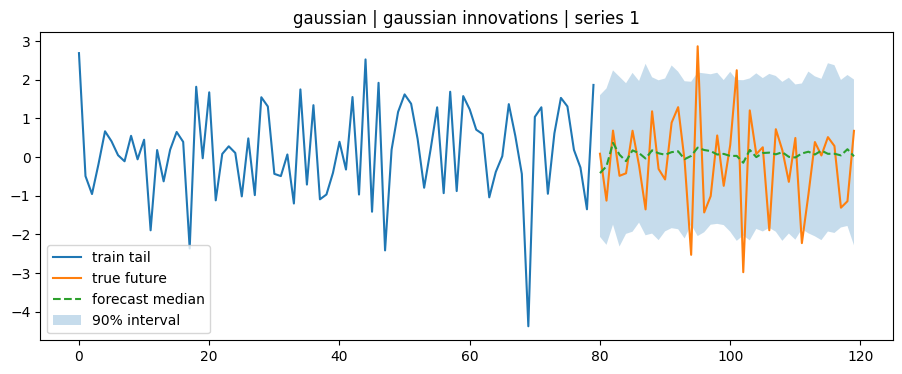

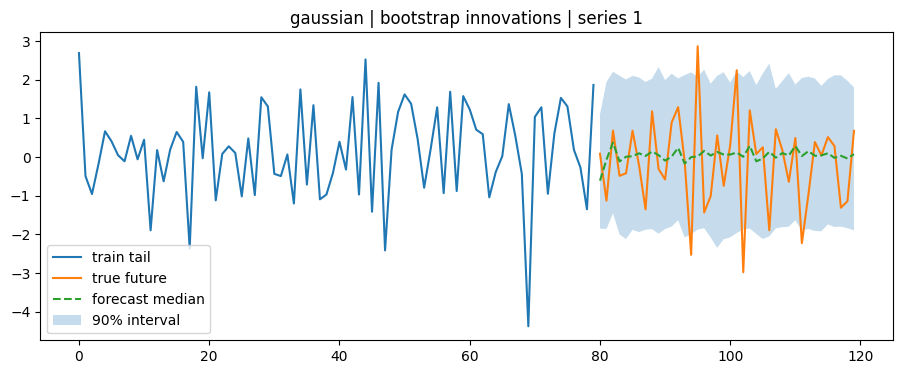

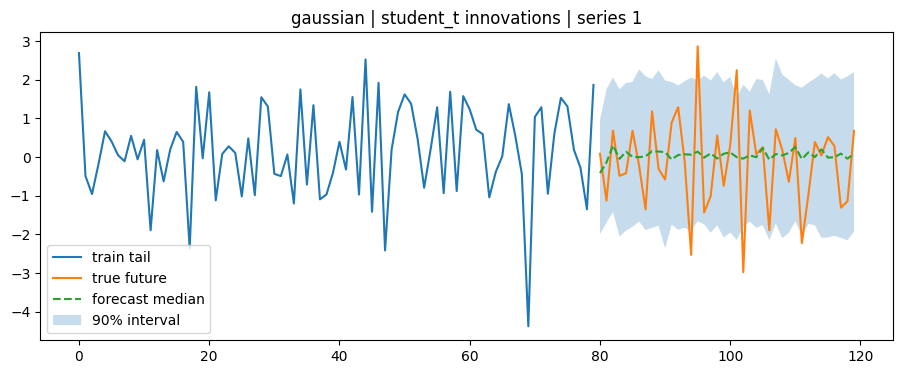

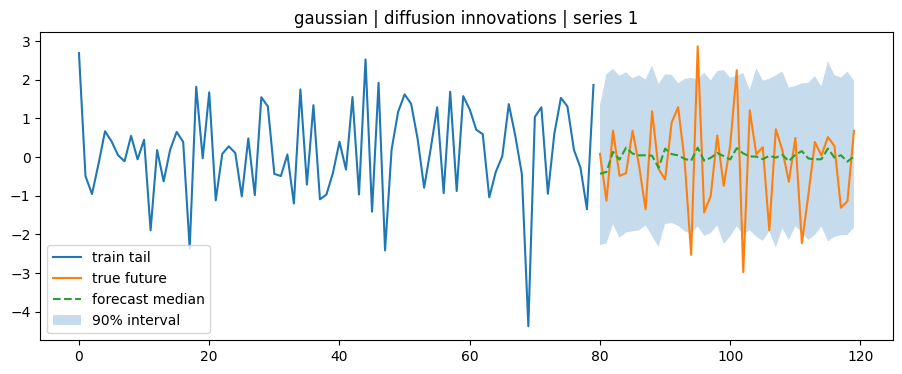

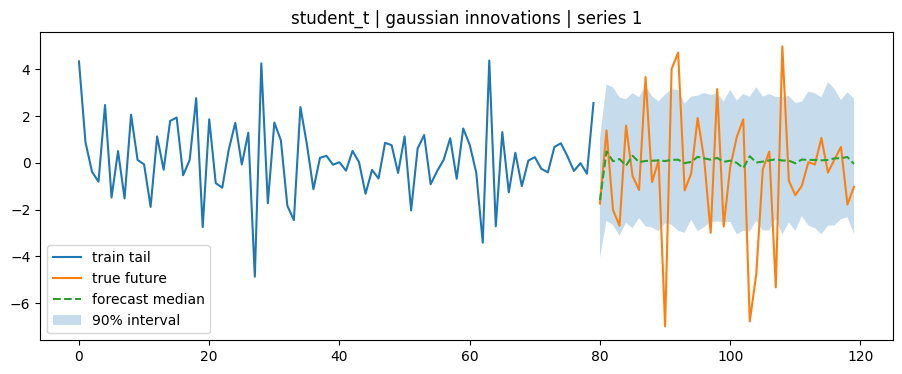

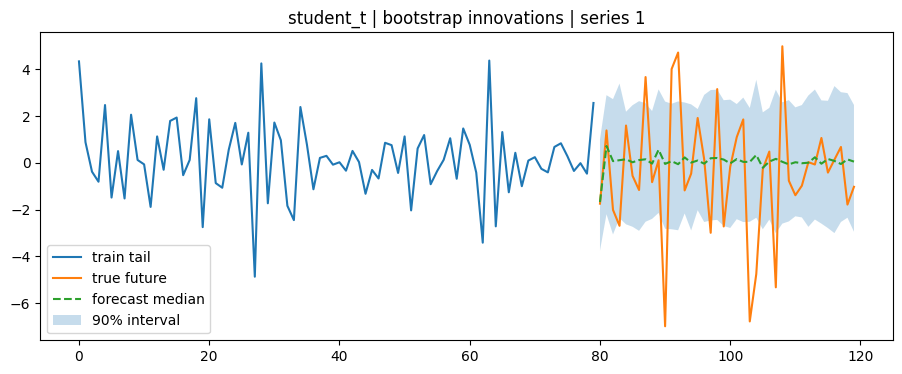

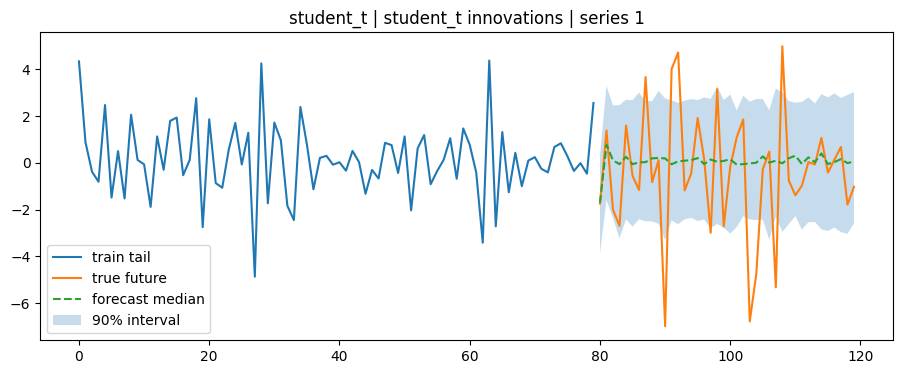

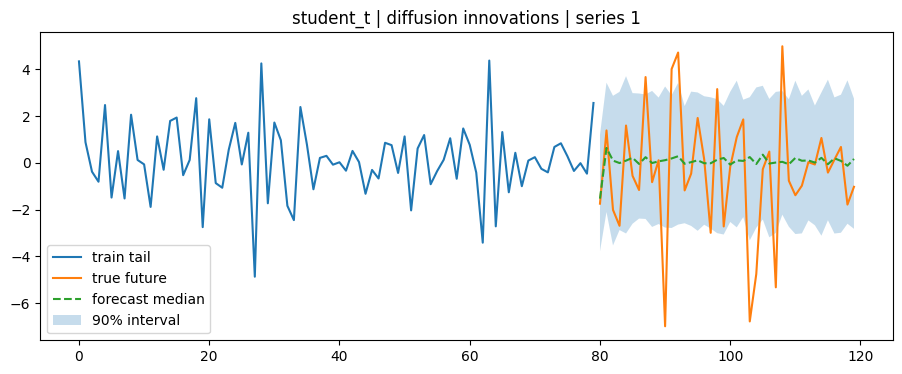

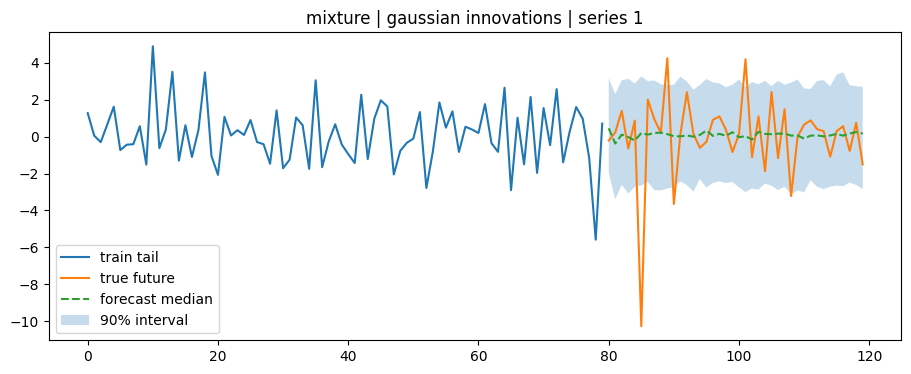

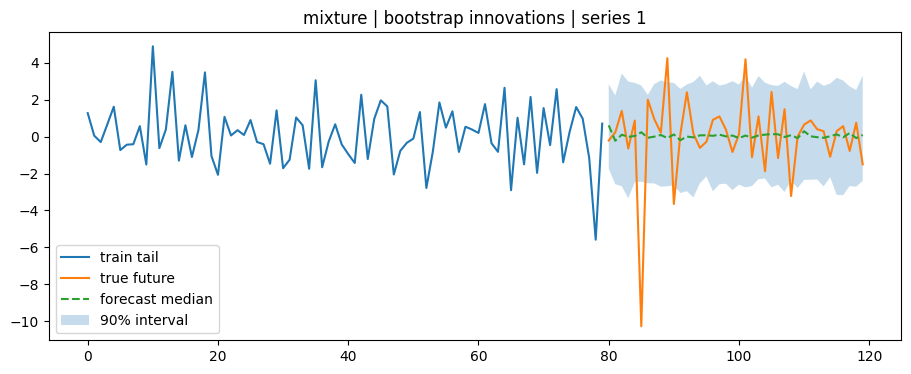

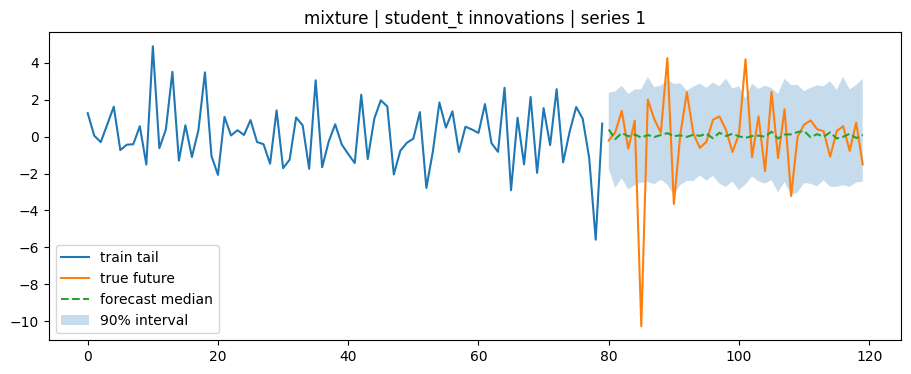

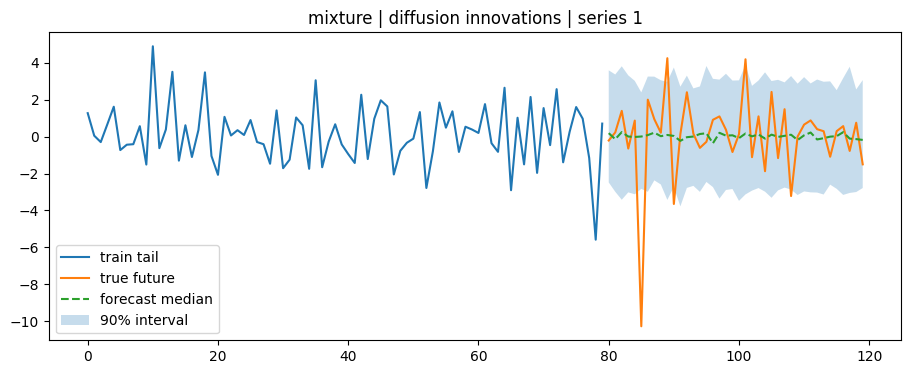

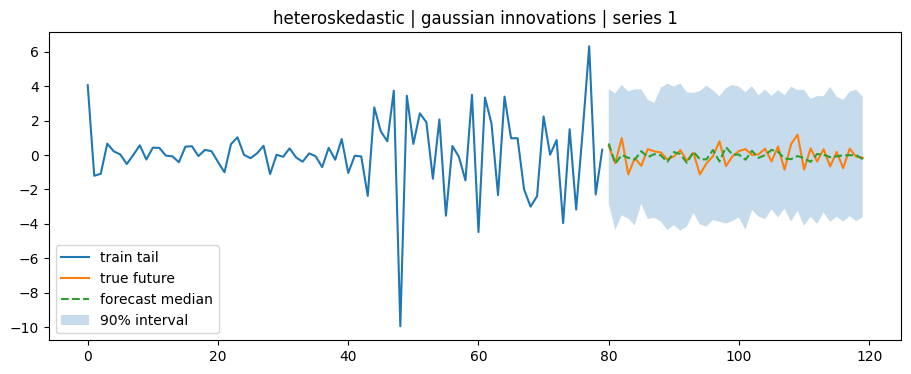

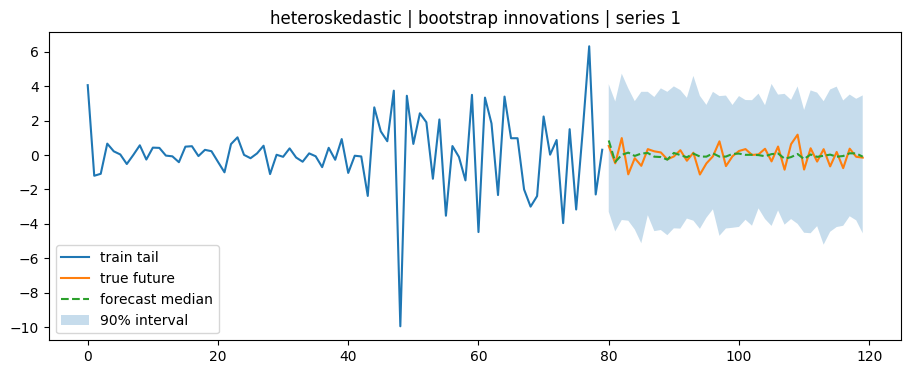

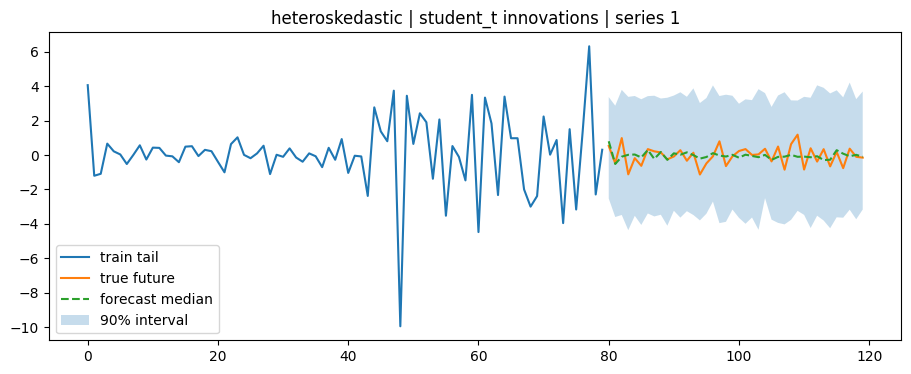

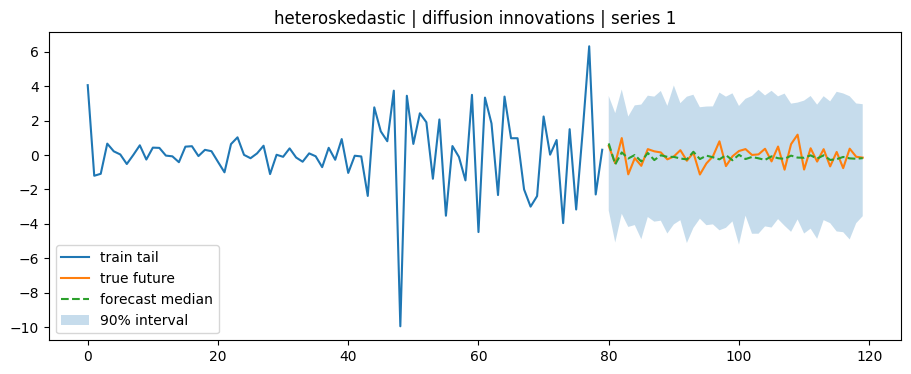

In [9]:
for dgp_name in dgp_names:
    for innovation_model in innovation_model_names:
        plot_forecast_intervals(
            dgp_name=dgp_name,
            innovation_model=innovation_model,
            variable=0,
        )

In [10]:
def plot_model_comparison(
    dgp_name,
    variable=0,
):
    y_train = datasets[dgp_name]["y_train"]
    y_true = datasets[dgp_name]["y_test"]

    train_tail = y_train[-80:, variable]
    x_train = np.arange(len(train_tail))
    x_forecast = np.arange(len(train_tail), len(train_tail) + horizon)

    plt.figure(figsize=(11, 5))

    plt.plot(
        x_train,
        train_tail,
        label="train tail",
    )

    plt.plot(
        x_forecast,
        y_true[:, variable],
        label="true future",
    )

    for innovation_model in innovation_model_names:
        paths = forecast_paths[dgp_name][innovation_model]
        median = median_forecast(paths)

        plt.plot(
            x_forecast,
            median[:, variable],
            linestyle="--",
            label=f"{innovation_model} median",
        )

    plt.title(f"{dgp_name}: forecast median comparison, series {variable + 1}")
    plt.legend()
    plt.show()

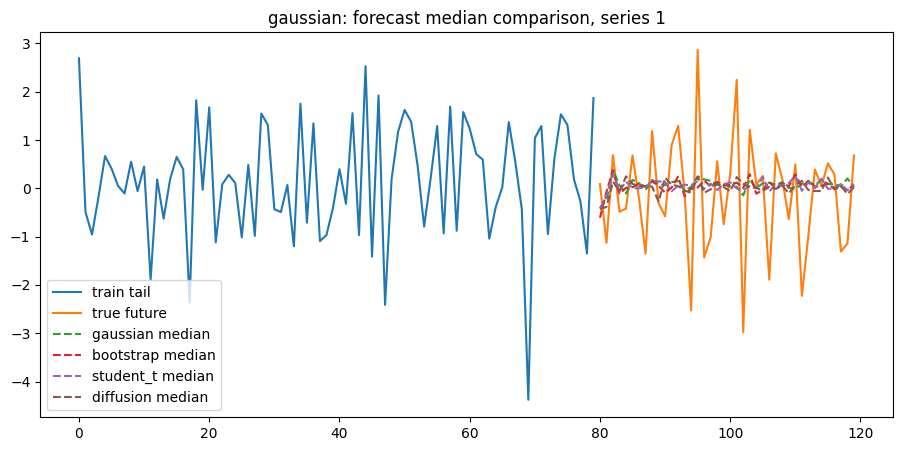

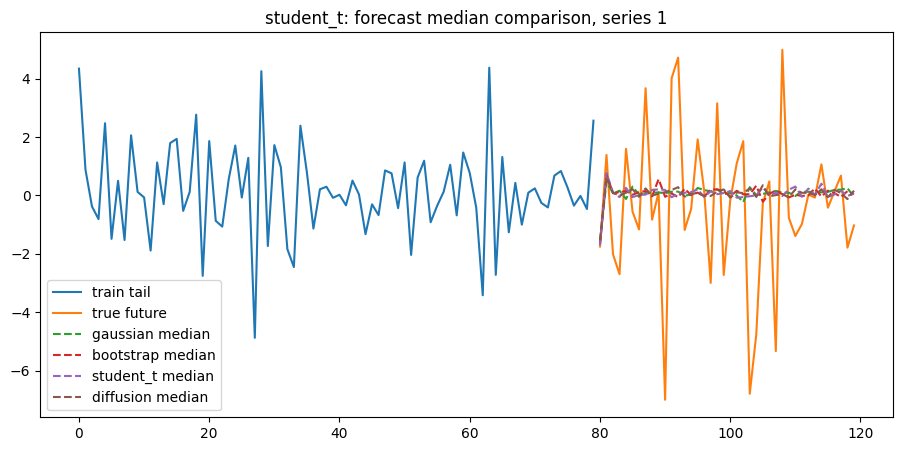

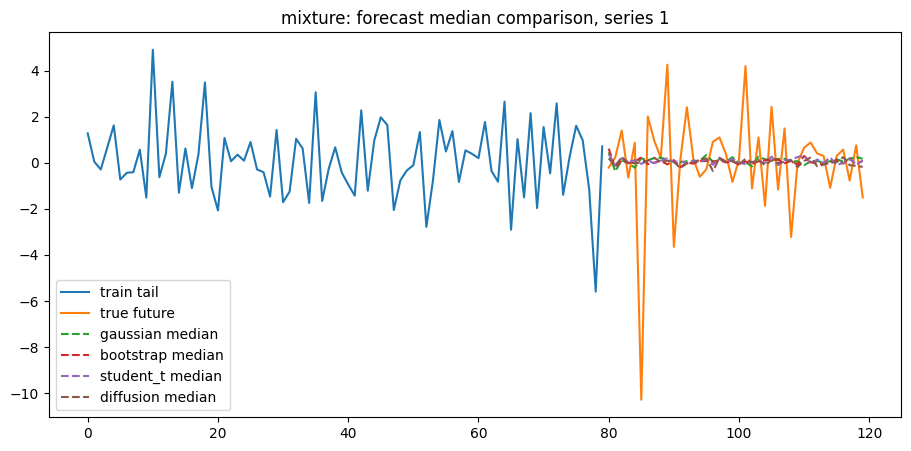

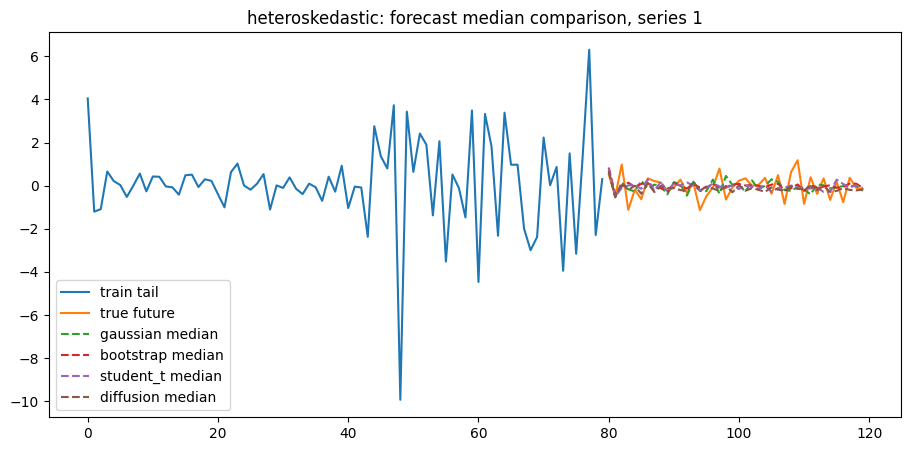

In [11]:
for dgp_name in dgp_names:
    plot_model_comparison(
        dgp_name=dgp_name,
        variable=0,
    )

In [12]:
width_rows = []

for dgp_name in dgp_names:
    for innovation_model in innovation_model_names:
        paths = forecast_paths[dgp_name][innovation_model]

        lower, upper = prediction_interval(
            paths,
            lower_q=0.05,
            upper_q=0.95,
        )

        width = average_interval_width(
            lower=lower,
            upper=upper,
        )

        width_rows.append({
            "dgp": dgp_name,
            "innovation_model": innovation_model,
            "avg_width": float(width.mean()),
            "width_1": float(width[0]),
            "width_2": float(width[1]),
            "width_3": float(width[2]),
        })

width_df = pd.DataFrame(width_rows)
width_df

,dgp,innovation_model,avg_width,width_1,width_2,width_3
0,gaussian,gaussian,3.730880,4.047602,3.524876,3.620163
1,gaussian,bootstrap,3.663531,3.943443,3.552684,3.494465
2,gaussian,student_t,3.526298,3.861631,3.298324,3.418940
3,gaussian,diffusion,3.661504,4.038879,3.342484,3.603148
4,student_t,gaussian,5.108414,5.621880,5.052529,4.650834
5,student_t,bootstrap,4.760542,5.291312,4.749165,4.241148
6,student_t,student_t,4.828365,5.365158,4.748382,4.371555
7,student_t,diffusion,5.120182,5.755243,4.995884,4.609418
8,mixture,gaussian,5.266876,5.632926,5.151333,5.016368
9,mixture,bootstrap,4.941106,5.532775,4.911664,4.378880


In [13]:
save_table_csv(
    width_df,
    table_dir / "forecast_interval_widths.csv",
)

In [14]:
run_dir = make_run_dir(
    base_dir=ROOT / "logs" / "experiments",
    run_name="06_forecasts",
)

metrics = {
    "notebook": "06_forecasts",
    "forecast_model": "VAR",
    "dgp_names": dgp_names,
    "innovation_model_names": innovation_model_names,
    "lags": lags,
    "n_train": n_train,
    "horizon": horizon,
    "n_paths": n_paths,
    "forecast_paths_saved": True,
}

save_metrics_json(
    metrics,
    run_dir / "forecast_config.json",
)

print("saved forecasts to:", forecast_dir)
print("saved tables to:", table_dir)
print("saved logs to:", run_dir)

saved forecasts to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/forecasts/06_forecasts
saved tables to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/tables/06_forecasts
saved logs to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/logs/experiments/20260609_091531_06_forecasts
